<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Artificial_Intelligence/blob/main/Regress%C3%A3o_linear/Rela%C3%A7%C3%B5es_Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importando dados

In [1]:
data_house_url = 'https://raw.githubusercontent.com/YuriArduino/Estudos_Artificial_Intelligence/refs/heads/main/Pre%C3%A7os_de_casas.csv'

In [2]:
import pandas as pd


data_house = pd.read_csv(data_house_url)
data_house.head()

,Id,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0
2,3,85.4680,1,80.4514,2,608,0,1101855.0
3,4,89.2769,1,70.2324,1,642,0,690200.0
4,5,106.3705,1,97.8237,2,836,0,1232500.0


In [3]:
data_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
data_house.drop(columns = 'Id', inplace=True)
data_house.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


#Correlação e análise

Quais fatores se realacionam. O coeficiente de Pearson nos permite medir a relação linear entre variáveis, oferecendo uma escala que varia de -1 a 1, interpretada conforme sua intensidade e direção:


*   -1: positiva perfeita: ambas aumentam
*    0: não há relação entre variáveis
*    1: negativa perfeita: aumento proporcional ao decréscimo de outra variável.

In [5]:
corr = data_house.corr()

In [6]:
corr['preco_de_venda']

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


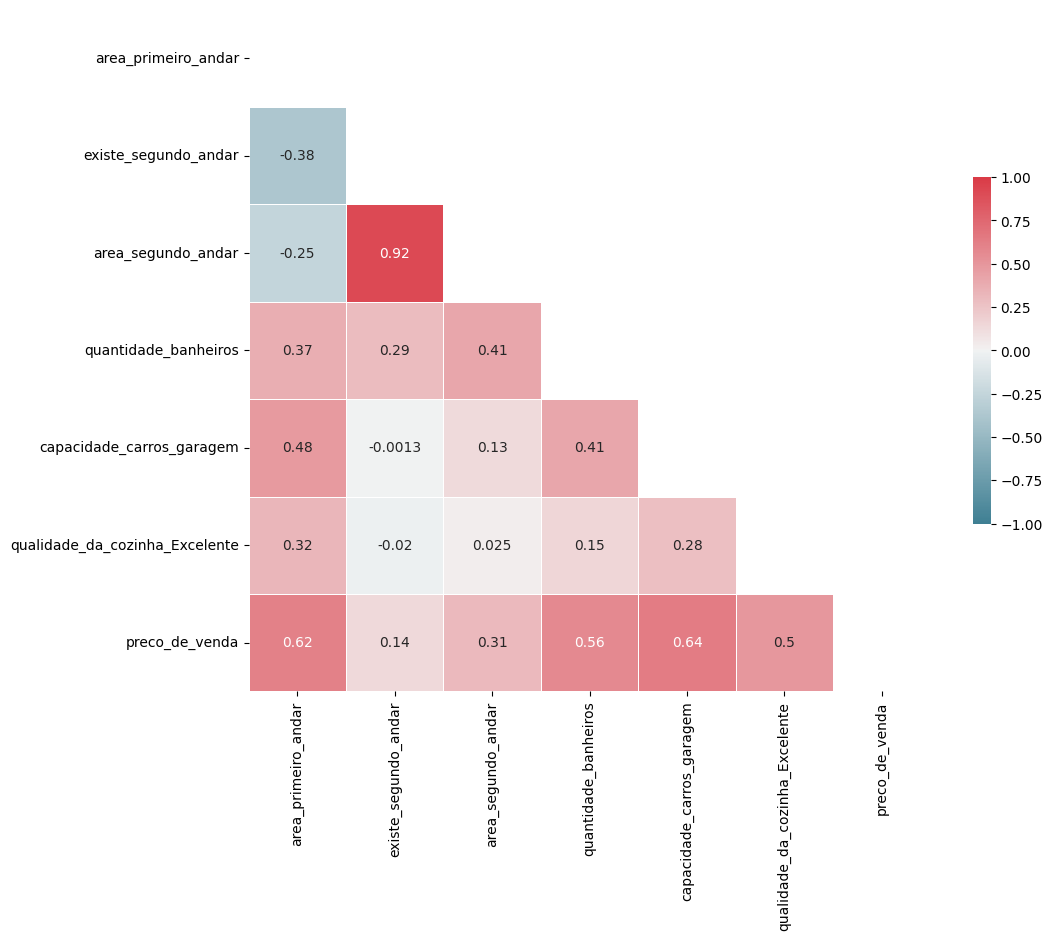

In [7]:
# Atividade
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

Text(0, 0.5, 'Preço de venda')

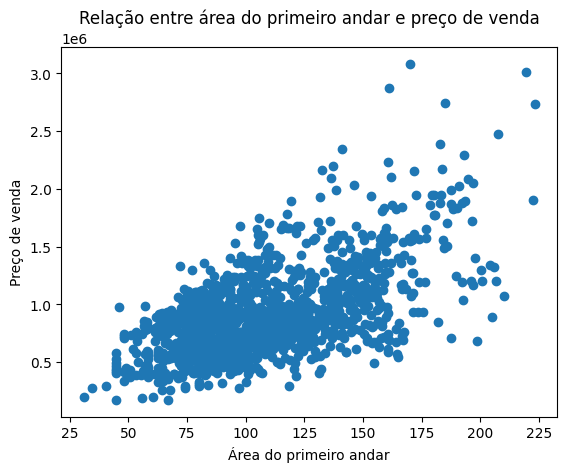

In [8]:
import plotly.express as px

plt.scatter(data_house['area_primeiro_andar'], data_house['preco_de_venda'])
plt.title('Relação entre área do primeiro andar e preço de venda')
plt.xlabel('Área do primeiro andar')
plt.ylabel('Preço de venda')

Text(0, 0.5, 'Preço de venda')

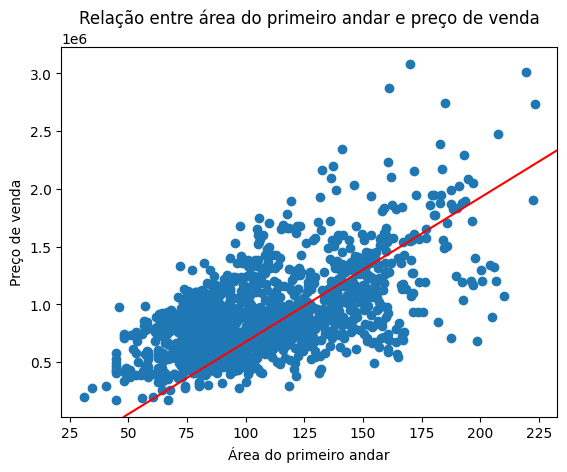

In [9]:
import plotly.express as px

plt.scatter(data_house['area_primeiro_andar'], data_house['preco_de_venda'])
plt.axline(xy1 =(66,250000),xy2 = (190,1800000), color='red')

plt.title('Relação entre área do primeiro andar e preço de venda')
plt.xlabel('Área do primeiro andar')
plt.ylabel('Preço de venda')

In [10]:
px.scatter(data_house, x='area_primeiro_andar', y='preco_de_venda',trendline_color_override='red', trendline='ols')

Text(5.069444444444445, 0.5, 'Densidade')

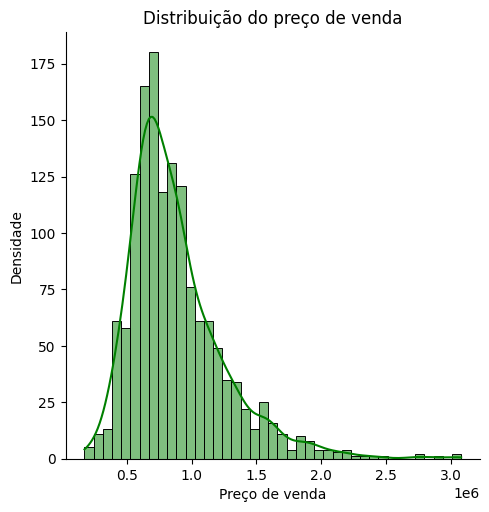

In [11]:
sns.displot(
    data_house['preco_de_venda'],
    kde=True,
    color='green'
)

plt.title('Distribuição do preço de venda')
plt.xlabel('Preço de venda')
plt.ylabel('Densidade')

#ML

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
y = data_house['preco_de_venda']
x = data_house.drop(columns='preco_de_venda')

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=459)

In [15]:
df_train = pd.DataFrame(data=x_train)
df_train['preco_de_venda'] = y_train
df_train.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
425,44.8707,1,46.8216,1,264,0,421022.0
602,120.6771,1,53.2317,2,531,1,1289195.0
598,180.2260,1,116.4966,2,380,0,1770363.0
371,83.9816,0,0.0000,0,0,0,300730.0
773,83.7029,0,0.0000,1,281,0,531947.0


In [16]:
from statsmodels.formula.api import ols

modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data=df_train).fit()
modelo_0.params

,0
Intercept,166462.266198
area_primeiro_andar,6629.434837


In [17]:
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     582.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          7.49e-102
Time:                        17:34:32   Log-Likelihood:                -14072.
No. Observations:                1006   AIC:                         2.815e+04
Df Residuals:                    1004   BIC:                         2.816e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.665e+05   3

*   Variável Resposta (Y): Também chamada de variável dependente é aquela que estamos tentando prever.
*   Intercept (β₀): O ponto onde a linha de regressão intercepta o eixo vertical (Y), ou seja, o valor de Y quando X é igual a 0.
*   Variável Explicativa (X): Também chamada de variável independente e é o fator que usamos para prever e explicar a variável resposta.
Coeficientes de Regressão (β₁): Impacto de cada variável explicativa X na variável resposta, é o efeito de X em Y.
*   Erro Residual (e): Diferença entre os valores reais e previstos da variável resposta.

Coeficientes


A relação linear entre as variáveis X e Y é representada graficamente por uma linha. Este processo de encontrar a linha ideal envolve minimizar a distância entre os pontos reais e a própria linha.

O ajuste da linha de regressão linear é simplificado pelo **método dos mínimos quadrados**:
> Este método visa encontrar a linha que melhor se ajusta aos dados observados, minimizando a soma dos quadrados das diferenças entre os valores reais e os valores previstos pela linha e calculando os coeficientes do modelo.

In [18]:
modelo_0.rsquared

np.float64(0.3671397901233372)

R² = COEFICIENTE DE DETERMINAÇÃO.

Ele varia de 0 a 1, um valor próximo de 1 indica que o modelo ajusta bem os dados, explicando a maioria da variação na variável dependente/resposta. Já um valor próximo de 0 indica que o modelo não consegue explicar muita variação na variável dependente/resposta.

>Além disso, o R² pode ser usado para comparar o desempenho do modelo em diferentes conjuntos de dados, como treinamento e teste. Isso ajuda a identificar problemas de overfitting (ajuste excessivo) ou underfitting (ajuste insuficiente). Idealmente, desejamos que o R² seja consistente entre os conjuntos de treinamento e teste, indicando uma boa capacidade de generalização do modelo para novos dados.

##Resíduo

Quanto menor essa diferença, mais preciso e assertivo será nosso modelo na previsão dos preços de venda das casas. Ou seja a diferença entre o valor observado e o valor estimado.

In [19]:
modelo_0.resid

,0
425,-42907.647937
602,322711.763037
598,409104.210873
371,-422482.810903
773,-189418.187414
...,...
343,-300249.771811
1369,52879.126861
1184,-120247.695257
188,262429.661109


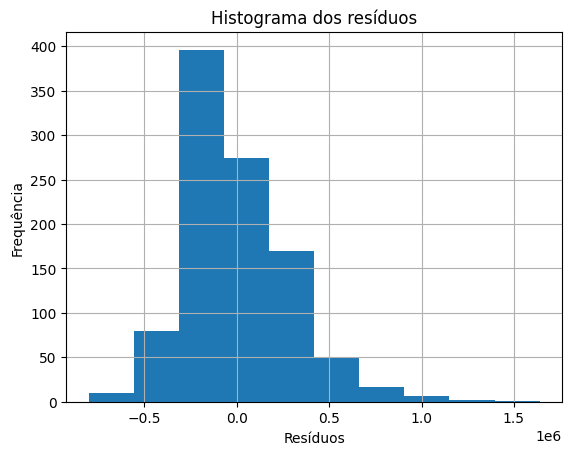

In [20]:
modelo_0.resid.hist()
plt.title('Histograma dos resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

#O resultado visa um formato de sino

## R² da previsão

In [21]:
y_predict = modelo_0.predict(x_test)

In [22]:
from sklearn.metrics import r2_score
#print r²
print("R²: ", r2_score(y_test, y_predict))


#0.3671397901233372 valor encontrado no treino

R²:  0.40101916536005056


# Outros fatores

o modelo apresentou um valor aproximado de 0,37, ou seja, aproximadamente 37% da variação observada nos preços das casas podem ser explicadas pela variação na área. Portanto ainda temos por volta de 63% de fatores além da area para explicar o preço das casas.

#Cruzando e analizando dados com o perplot

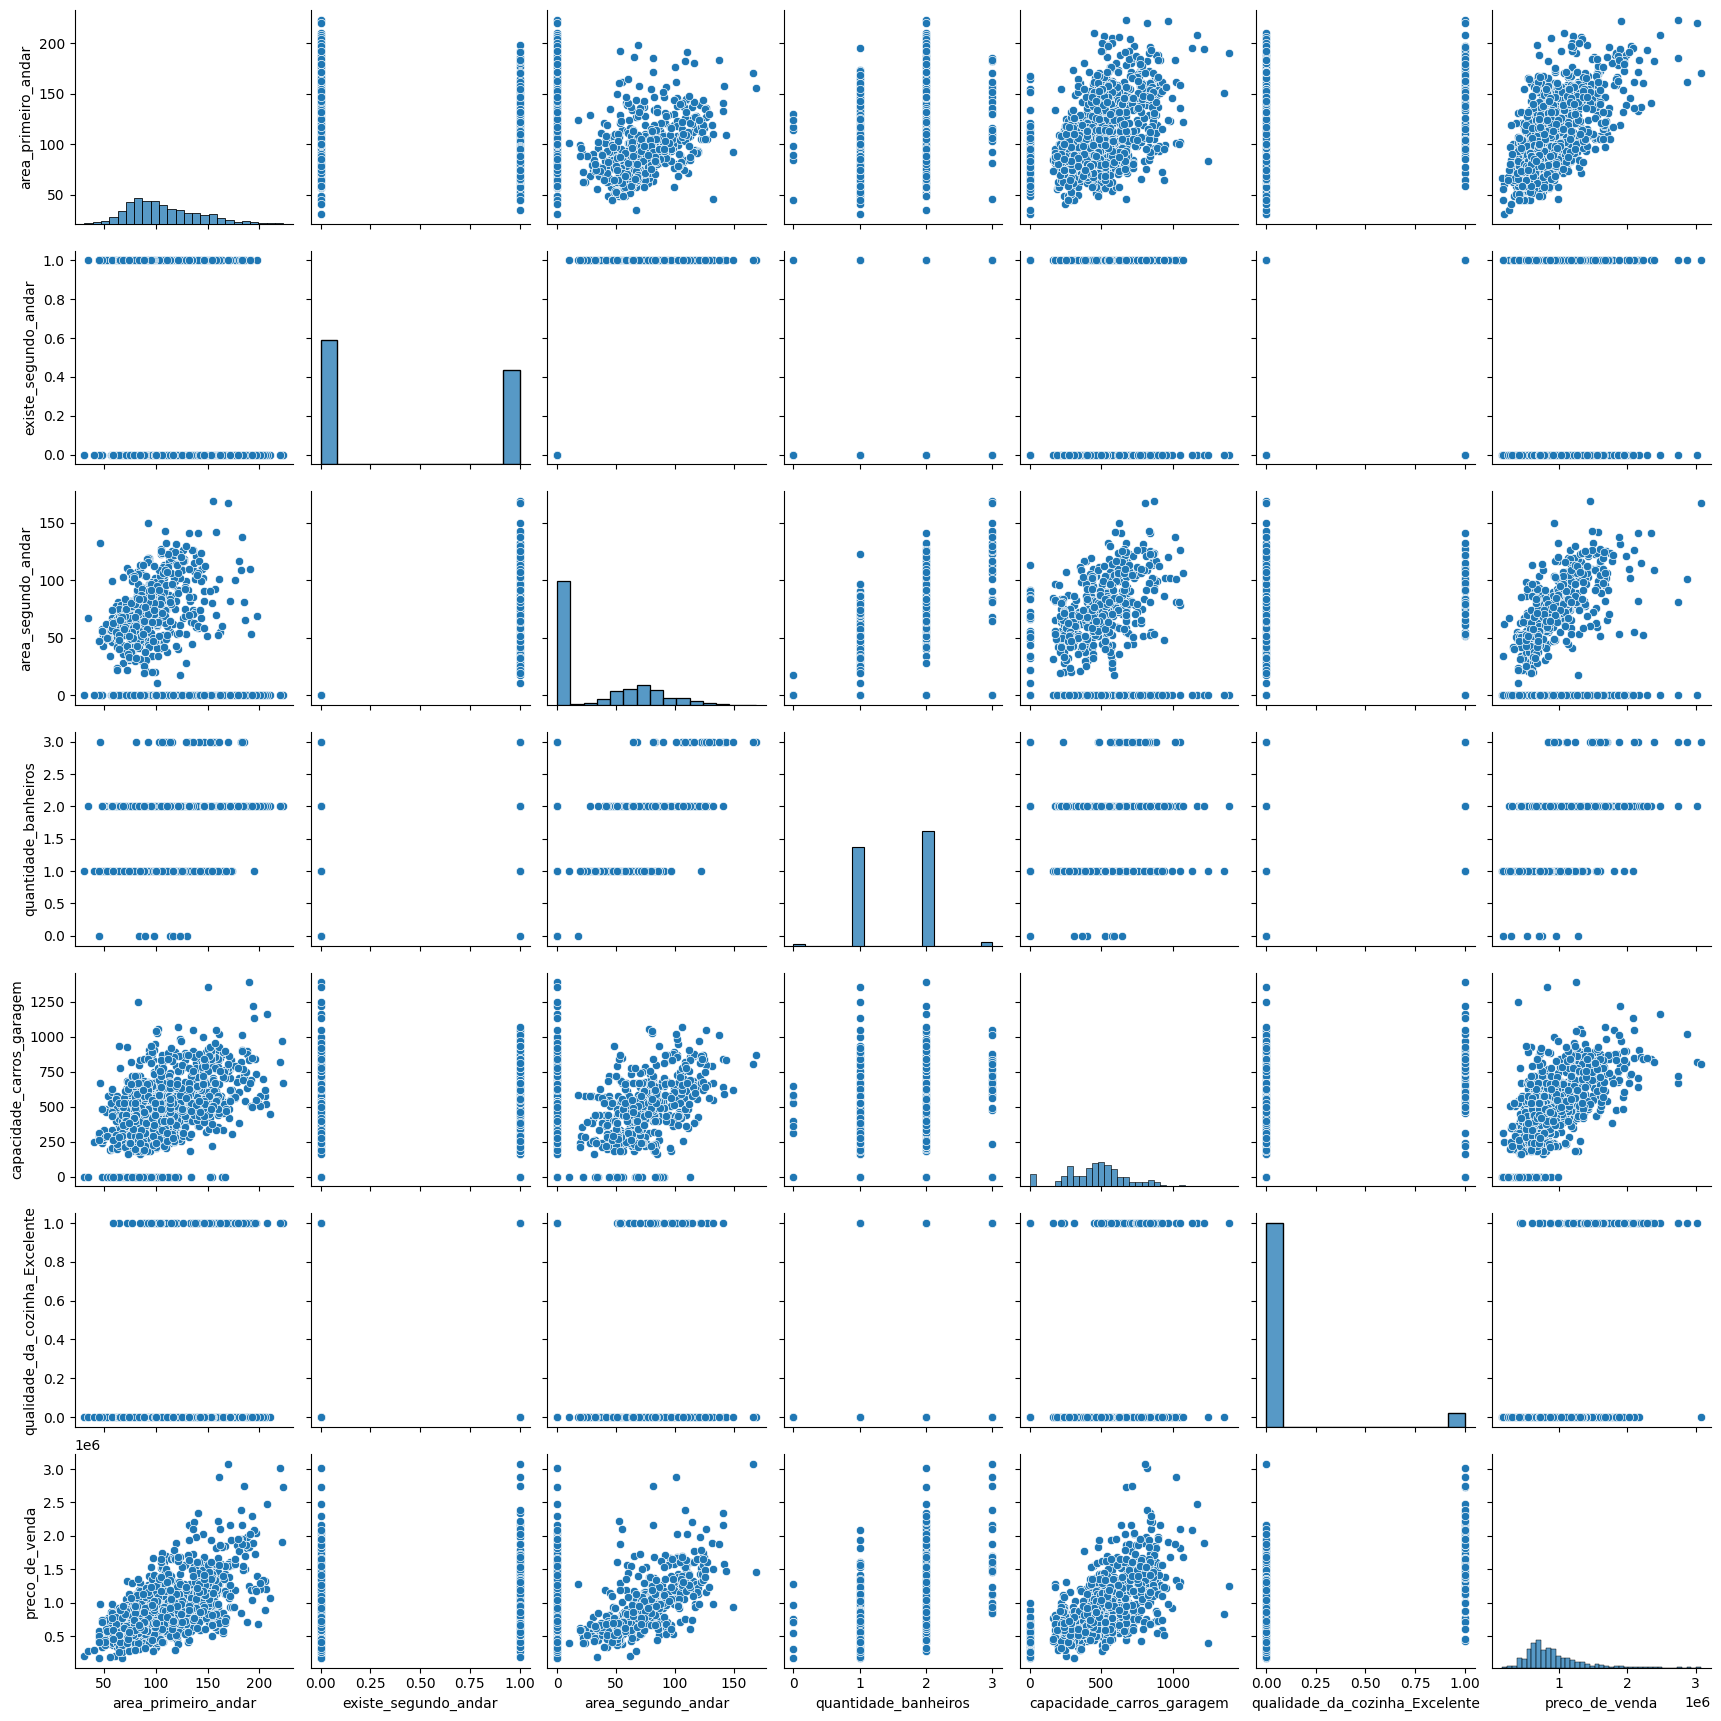

In [23]:
sns.pairplot(data_house)

In [24]:
data_house.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='object')

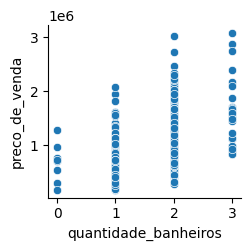

In [25]:
sns.pairplot(data_house, y_vars = 'preco_de_venda', x_vars = 'quantidade_banheiros')

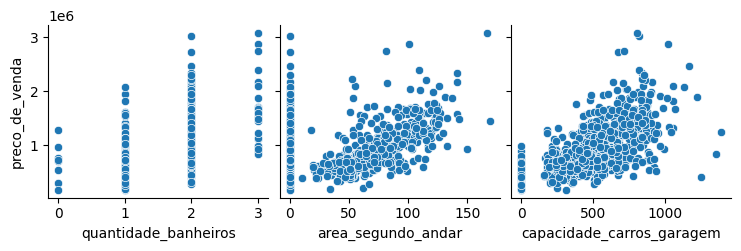

In [26]:
sns.pairplot(data_house, y_vars = 'preco_de_venda', x_vars = [ 'quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])

#Adicionando fatores ao modelo

In [27]:
import statsmodels.api as sm

In [28]:
x_train = sm.add_constant(x_train)

In [29]:
print (x_train.head())

     const  area_primeiro_andar  existe_segundo_andar  area_segundo_andar  \
425    1.0              44.8707                     1             46.8216   
602    1.0             120.6771                     1             53.2317   
598    1.0             180.2260                     1            116.4966   
371    1.0              83.9816                     0              0.0000   
773    1.0              83.7029                     0              0.0000   

     quantidade_banheiros  capacidade_carros_garagem  \
425                     1                        264   
602                     2                        531   
598                     2                        380   
371                     0                          0   
773                     1                        281   

     qualidade_da_cozinha_Excelente  
425                               0  
602                               1  
598                               0  
371                               0  
773       

In [30]:
x_train.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [31]:
#Criando modelo de regressão (sem fórmula): saturado

modelo_1 = sm.OLS(
    y_train,
    x_train [
        [
        'const',
        'area_primeiro_andar',
        'existe_segundo_andar',
        'area_segundo_andar',
        'quantidade_banheiros',
        'capacidade_carros_garagem',
        'qualidade_da_cozinha_Excelente'
        ]
      ]
    ).fit()
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     427.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          8.48e-272
Time:                        17:34:44   Log-Likelihood:                -13662.
No. Observations:                1006   AIC:                         2.734e+04
Df Residuals:                     999   BIC:                         2.737e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [32]:
#Modelo sem área do segundo andar

modelo_2 = sm.OLS(
    y_train,
    x_train [
        [
        'const',
        'area_primeiro_andar',
        'existe_segundo_andar',
        'quantidade_banheiros',
        'capacidade_carros_garagem',
        'qualidade_da_cozinha_Excelente'
        ]
      ]
    ).fit()
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     460.9
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          1.42e-256
Time:                        17:34:44   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [33]:
#Modelo sem área do segundo andar e informações sobre garagem

modelo_3 = sm.OLS(
    y_train,
    x_train [
        [
        'const',
        'area_primeiro_andar',
        'existe_segundo_andar',
        'quantidade_banheiros',
        'qualidade_da_cozinha_Excelente'
        ]
      ]
    ).fit()
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     428.0
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          6.16e-215
Time:                        17:34:44   Log-Likelihood:                -13801.
No. Observations:                1006   AIC:                         2.761e+04
Df Residuals:                    1001   BIC:                         2.764e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

##Comparando modelos

In [34]:
print("Resultados R²")
print("Modelo 0: ", modelo_0.rsquared)
print("Modelo 1: ", modelo_1.rsquared)
print("Modelo 2: ", modelo_2.rsquared)
print("Modelo 3: ", modelo_3.rsquared)

Resultados R²
Modelo 0:  0.3671397901233372
Modelo 1:  0.7196647056765761
Modelo 2:  0.6973660565681961
Modelo 3:  0.6310130296910961


In [35]:
#Quantos parametros estão no modelos?

print("Modelo 0: ", len(modelo_0.params))
print("Modelo 1: ", len(modelo_1.params))
print("Modelo 2: ", len(modelo_2.params))
print("Modelo 3: ", len(modelo_3.params))

Modelo 0:  2
Modelo 1:  7
Modelo 2:  6
Modelo 3:  5


Além da seleção manual que discutimos, existem métodos automáticos de seleção de variáveis que podem ser extremamente úteis em situações onde o número de variáveis explicativas é grande.

 Esses métodos, como:

  *   stepwise,
  *   backward,
  *   forward selection,
  
   seguem critérios pré-definidos para adicionar ou remover variáveis do modelo de forma iterativa. Explore a seguir os métodos automáticos de seleção de variáveis, que visam equilibrar a complexidade do modelo e sua capacidade explicativa.

*  Forward selection começa com um modelo sem variáveis explicativas e adiciona uma a uma, escolhendo em cada passo a variável que mais melhora o modelo de acordo com um critério estatístico específico, como o menor valor de p-valor ou o maior aumento no R² ajustado.

*  Backward selection inicia com todas as variáveis possíveis no modelo e, iterativamente, remove a variável que menos contribui para o modelo, novamente baseando-se em critérios como o p-valor ou o impacto no R² ajustado.


*  Stepwise selection é uma combinação dos dois métodos anteriores, onde as variáveis podem ser adicionadas ou removidas em cada passo, dependendo de sua contribuição para o melhoramento do modelo.


Esses métodos de seleção automática são ferramentas poderosas que ajudam na identificação do modelo mais parcimonioso, ou seja, aquele que consegue explicar os dados de maneira eficiente sem ser excessivamente complexo. Contudo, é crucial que o cientista de dados compreenda e supervisione o processo, pois a escolha automática pode, às vezes, introduzir viés ou sobreajuste, especialmente se o critério de seleção não for bem escolhido ou se o modelo não for validado adequadamente com dados novos ou de teste.

In [36]:
modelo_3.params

,0
const,-105123.810819
area_primeiro_andar,5818.542824
existe_segundo_andar,188613.948531
quantidade_banheiros,161058.462494
qualidade_da_cozinha_Excelente,437382.604341


Cada um desses adiciona um valor substancial ao valor final da casa como a qualidade da cozinha que aumenta cerca de 450k ao preço final da casa. Essa é uma análise de efeito isolado resultando da regressão linear.

#Precificando as casas

## Obtendo o R² da previsão

In [40]:
x_test.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [38]:
modelo_3.params

,0
const,-105123.810819
area_primeiro_andar,5818.542824
existe_segundo_andar,188613.948531
quantidade_banheiros,161058.462494
qualidade_da_cozinha_Excelente,437382.604341


In [39]:
x_test= sm.add_constant(x_test)

In [41]:
predict3 = modelo_3.predict(x_test[
    ['const',
     'area_primeiro_andar',
     'existe_segundo_andar',
     'quantidade_banheiros',
    'qualidade_da_cozinha_Excelente'
    ]
  ]
)

In [42]:
modelo_3.rsquared

np.float64(0.6310130296910961)

In [43]:
print("R²: ", r2_score(y_test, predict3))

R²:  0.6822301097988112


In [45]:
modelo_3.params

,0
const,-105123.810819
area_primeiro_andar,5818.542824
existe_segundo_andar,188613.948531
quantidade_banheiros,161058.462494
qualidade_da_cozinha_Excelente,437382.604341


In [47]:
#novo imovel

novo_imovel = pd.DataFrame(
    {
     'const'                        : [1],
     'area_primeiro_andar'          : [120],
     'existe_segundo_andar'         : [1],
     'quantidade_banheiros'         : [2],
    'qualidade_da_cozinha_Excelente': [0]
  }
)

novo_imovel

,const,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1,120,1,2,0


In [48]:
#Teste modelo 0

modelo_0.predict(novo_imovel['area_primeiro_andar'])

,0
0,961994.446635


In [54]:
#Teste modelo 3

print (modelo_3.predict(novo_imovel)[0])

1103832.2015847256


In [61]:
novas_casas_url = 'https://raw.githubusercontent.com/YuriArduino/Estudos_Artificial_Intelligence/refs/heads/main/Novas_casas.csv'
novas_casas = pd.read_csv(novas_casas_url, sep= ';')
print(novas_casas.head())

   Casa  area_primeiro_andar  existe_segundo_andar  quantidade_banheiros  \
0     1                  150                     1                     2   
1     2                  180                     0                     3   
2     3                  120                     1                     2   
3     4                  200                     1                     3   
4     5                  160                     0                     2   

   qualidade_da_cozinha_Excelente  
0                               1  
1                               1  
2                               1  
3                               1  
4                               1  


In [62]:
novas_casas.drop(columns='Casa', inplace=True)
novas_casas.head()

,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1,150,1,2,1
1,2,180,0,3,1
2,3,120,1,2,1
3,4,200,1,3,1
4,5,160,0,2,1


In [69]:
novas_casa = sm.add_constant(novas_casas)
novas_casa.head(10)

,const,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1.0,1,150,1,2,1
1,1.0,2,180,0,3,1
2,1.0,3,120,1,2,1
3,1.0,4,200,1,3,1
4,1.0,5,160,0,2,1
5,1.0,6,140,1,2,0
6,1.0,7,170,0,3,0
7,1.0,8,190,1,2,0
8,1.0,9,130,0,2,0
9,1.0,10,180,1,3,0


In [66]:
print (modelo_3.predict(novas_casas))

0    1.715771e+06
1    1.757648e+06
2    1.330967e+06
3    1.852385e+06
4    1.164847e+06
5    6.945840e+05
6    7.364610e+05
7    7.752635e+05
8    1.324132e+05
9    6.678889e+05
dtype: float64


#Investigando a muticolinearidade

## Dois ou mais fatores muito próximos dificultando a análise da origem da influência sob o resultado.

In [70]:
#Import VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [71]:
explicativas_1 = [
    'const',
    'area_primeiro_andar',
    'existe_segundo_andar',
    'area_segundo_andar',
    'quantidade_banheiros',
    'capacidade_carros_garagem',
    'qualidade_da_cozinha_Excelente'
]

explicativas_2 = [
    'const',
    'area_primeiro_andar',
    'existe_segundo_andar',
    'quantidade_banheiros',
    'capacidade_carros_garagem',
    'qualidade_da_cozinha_Excelente'
]

explicativas_3 = [
    'const',
    'area_primeiro_andar',
    'existe_segundo_andar',
    'quantidade_banheiros',
    'qualidade_da_cozinha_Excelente'
]

In [77]:
#Vif 1

vif_1 = pd.DataFrame()
vif_1['variavel'] = explicativas_1

vif_1['VIF'] = [variance_inflation_factor(x_train[explicativas_1].values, i)
 for i in range(len(explicativas_1))]

vif_1

#Menor vif, menor efeito da multicolinearidade (indicado <5)

,variavel,VIF
0,const,19.742184
1,area_primeiro_andar,1.964280
2,existe_segundo_andar,7.693566
3,area_segundo_andar,7.805099
4,quantidade_banheiros,1.740448
5,capacidade_carros_garagem,1.449622
6,qualidade_da_cozinha_Excelente,1.120173


In [76]:
vif_3 = pd.DataFrame()
vif_3['variavel'] = explicativas_3

vif_3['VIF'] = [variance_inflation_factor(x_train[explicativas_3].values, i)
 for i in range(len(explicativas_3))]

vif_3

,variavel,VIF
0,const,17.856357
1,area_primeiro_andar,1.764106
2,existe_segundo_andar,1.602489
3,quantidade_banheiros,1.571472
4,qualidade_da_cozinha_Excelente,1.106593


#Análise dos resíduos

## Discrepância entre os valores reais e os valores que o modelo prevê para os mesmos pontos de dados

In [90]:
y_previsto_train = modelo_3.predict(x_train[explicativas_3])

In [92]:
fig = px.scatter(
    x= y_previsto_train,
    y= y_train,
    title='Previsão x Real',
    labels={'x': 'Previsão', 'y': 'Preço Real'}
)
fig.show()

Identificando homocedasticidade:

  >Não existe um padrão, persiste a aleatoriedade desejada

In [86]:
residuos_03 = modelo_3.resid

<Axes: title={'center': 'Resíduos x Previsão'}, xlabel='Preço Casa -Previsão', ylabel='Resíduos'>

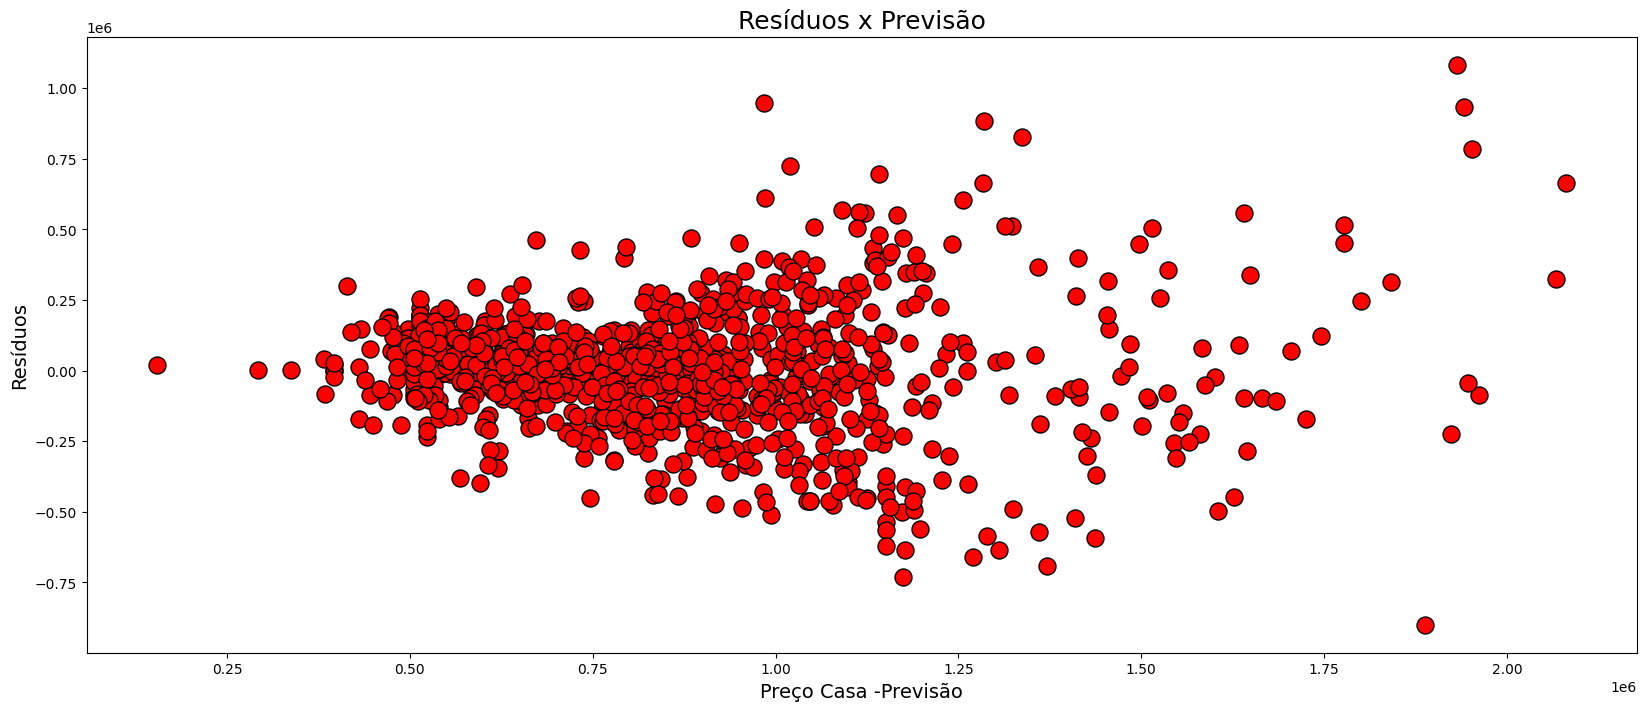

In [102]:
ax = sns.scatterplot(
    x=y_previsto_train,
    y=residuos_03,
    color='red',
    s=150,
    edgecolor='black'
)

ax.figure.set_size_inches(20, 8)

ax.set_title(
    'Resíduos x Previsão',
    fontsize=18
    )
ax.set_xlabel(
    'Preço Casa -Previsão',
    fontsize=14
    )
ax.set_ylabel(
    'Resíduos',
    fontsize=14
    )

ax